# Colorado GUNW comparison: controlled and SnowIn-native modes

This notebook compares one real Colorado NISAR GUNW edge in two clearly separated modes:

1. **Controlled mode** uses Colorado's incidence raster and frozen wavelength (`0.238403545 m`) to isolate phase, reference, and dSWE lineage.
2. **SnowIn-native mode** uses `add_gunw_incidence()` with the NISAR-modified Copernicus DEM and the product-derived wavelength.

Set `SNOWIN_GUNW` before running. Set `SNOWIN_COLORADO_INCIDENCE` to enable controlled mode; the raster is expected in degrees. Set `SNOWIN_COLORADO_OFFSET_RAD` to the downstream raw-phase offset for the same edge. Set `SNOWIN_NISAR_DEM` to use a local DEM, or leave it unset to use SnowIn's normal cache/download path. To evaluate the Colorado analysis regions, also set `SNOWIN_ERB_VECTOR` and `SNOWIN_TAYLOR_VECTOR` to the basin files; optional layer names are `SNOWIN_ERB_LAYER` and `SNOWIN_TAYLOR_LAYER`.

In [1]:
import math
import os
from html import escape
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from IPython.display import HTML, display

from snowin import compute_dswe, reference_phase
from snowin.io import add_gunw_incidence, open_gunw
from snowin.spatial import rasterize_vector_mask

FROZEN_COLORADO_WAVELENGTH_M = 0.238403545

def required_path(name):
    text = os.environ.get(name) or input(f'Enter {name}: ').strip()
    if not text:
        raise RuntimeError(f'{name} is required for this notebook.')
    path = Path(text).expanduser().resolve()
    if not path.exists():
        raise FileNotFoundError(path)
    return path

GUNW_PATH = required_path('SNOWIN_GUNW')
DEM_PATH = os.environ.get('SNOWIN_NISAR_DEM')
DEM_PATH = Path(DEM_PATH).expanduser().resolve() if DEM_PATH else None
INCIDENCE_PATH = os.environ.get('SNOWIN_COLORADO_INCIDENCE')
INCIDENCE_PATH = Path(INCIDENCE_PATH).expanduser().resolve() if INCIDENCE_PATH else None
DOWNSTREAM_DSWE_PATH = os.environ.get('SNOWIN_COLORADO_DOWNSTREAM_DSWE')
DOWNSTREAM_DSWE_PATH = Path(DOWNSTREAM_DSWE_PATH).expanduser().resolve() if DOWNSTREAM_DSWE_PATH else None
REGION_SOURCES = {
    'east_river': (os.environ.get('SNOWIN_ERB_VECTOR'), os.environ.get('SNOWIN_ERB_LAYER')),
    'taylor': (os.environ.get('SNOWIN_TAYLOR_VECTOR'), os.environ.get('SNOWIN_TAYLOR_LAYER')),
}
RAW_OFFSET_RAD = float(os.environ.get('SNOWIN_COLORADO_OFFSET_RAD', '0.0'))

display(HTML(
    '<table>'
    f'<tr><th>Input</th><th>Value</th></tr>'
    f'<tr><td>GUNW</td><td><code>{escape(str(GUNW_PATH))}</code></td></tr>'
    f'<tr><td>Local NISAR DEM</td><td><code>{escape(str(DEM_PATH)) if DEM_PATH else "automatic download/cache"}</code></td></tr>'
    f'<tr><td>Controlled incidence</td><td><code>{escape(str(INCIDENCE_PATH)) if INCIDENCE_PATH else "not configured"}</code></td></tr>'
    f'<tr><td>Downstream raw offset [rad]</td><td><code>{RAW_OFFSET_RAD:.9f}</code></td></tr>'
    '</table>'
))

Enter SNOWIN_GUNW:  /Users/jtarrico/ch13_nisar_prelim/data/nisar/gunw/provisional/erb/asc/T019_F021/NISAR_L2_PR_GUNW_004_019_A_021_005_4000_SH_20251030T121115_20251030T121143_20251111T121116_20251111T121144_P05023_N_F_J_001


Input,Value
GUNW,/Users/jtarrico/ch13_nisar_prelim/data/nisar/gunw/provisional/erb/asc/T019_F021/NISAR_L2_PR_GUNW_004_019_A_021_005_4000_SH_20251030T121115_20251030T121143_20251111T121116_20251111T121144_P05023_N_F_J_001
Local NISAR DEM,automatic download/cache
Controlled incidence,not configured
Downstream raw offset [rad],0.000000000


## Controlled Colorado mode

This mode keeps the downstream geometry and frozen wavelength fixed. SnowIn normalizes the GUNW phase to `secondary_minus_reference`, so the downstream raw-phase offset is supplied with the opposite sign.

In [2]:
controlled = None
controlled_dswe = None
if INCIDENCE_PATH is None:
    display(HTML('<p><i>Controlled mode skipped: set <code>SNOWIN_COLORADO_INCIDENCE</code>.</i></p>'))
else:
    import rasterio

    controlled = open_gunw(
        GUNW_PATH,
        wavelength_m=FROZEN_COLORADO_WAVELENGTH_M,
        chunks=None,
        progress=True,
    )
    with rasterio.open(INCIDENCE_PATH) as source:
        incidence_deg = source.read(1)
    if incidence_deg.shape != controlled['phase'].shape:
        raise ValueError(f'incidence shape {incidence_deg.shape} does not match phase shape {controlled["phase"].shape}')
    incidence_rad = np.where(
        (incidence_deg >= 0.0) & (incidence_deg < 90.0),
        np.deg2rad(incidence_deg),
        np.nan,
    )
    controlled['incidence_angle'] = xr.DataArray(
        incidence_rad,
        dims=controlled['phase'].dims,
        coords=controlled['phase'].coords,
        name='incidence_angle',
        attrs={'units': 'rad', 'incidence_angle_reference': 'local', 'source_units': 'degrees'},
    )
    controlled = reference_phase(
        controlled,
        method='manual_offset',
        offset_rad=-RAW_OFFSET_RAD,
    )
    controlled_dswe = compute_dswe(
        controlled['phase_referenced'],
        controlled['incidence_angle'],
        wavelength_m=FROZEN_COLORADO_WAVELENGTH_M,
    ).rename('controlled_dswe')
    display(controlled)
    display(controlled[['phase', 'phase_referenced', 'incidence_angle']])


## SnowIn-native mode

This mode performs the real geometry calculation. It appends `incidence_angle` to the opened xarray Dataset, masks values outside the supported `[0, 90°)` domain, and uses the product-derived wavelength recorded by `open_gunw()`.

In [3]:
native = open_gunw(GUNW_PATH, chunks=None, progress=True)
incidence_kwargs = {'progress': True}
if DEM_PATH is not None:
    incidence_kwargs['nisar_cop30_dem'] = DEM_PATH
add_gunw_incidence(native, GUNW_PATH, **incidence_kwargs)
native_incidence = native['incidence_angle']
native_supported_incidence = native_incidence.where(
    (native_incidence >= 0.0) & (native_incidence < math.pi / 2.0)
)
native = reference_phase(
    native,
    method='manual_offset',
    offset_rad=-RAW_OFFSET_RAD,
)
native_dswe = compute_dswe(
    native['phase_referenced'],
    native_supported_incidence,
    wavelength_m=float(native.attrs['wavelength_m']),
).rename('native_dswe')
display(native)
display(native[['phase', 'phase_referenced', 'incidence_angle']])


[snowin] opening GUNW phase data from NISAR_L2_PR_GUNW_004_019_A_021_005_4000_SH_20251030T121115_20251030T121143_20251111T121116_20251111T121144_P05023_N_F_J_001
[snowin] starting explicit GUNW incidence calculation
[snowin] preparing DEM for local incidence
[snowin] locating NISAR Copernicus DEM tiles for GUNW
[snowin] downloading DEM tile DEM_N36_00_W109_00_C01.tif
[snowin] downloading DEM tile DEM_N36_00_W108_00_C01.tif
[snowin] downloading DEM tile DEM_N36_00_W107_00_C01.tif
[snowin] downloading DEM tile DEM_N36_00_W106_00_C01.tif
[snowin] downloading DEM tile DEM_N36_00_W105_00_C01.tif
[snowin] downloading DEM tile DEM_N36_00_W104_00_C01.tif
[snowin] downloading DEM tile DEM_N37_00_W109_00_C01.tif
[snowin] downloading DEM tile DEM_N37_00_W108_00_C01.tif
[snowin] downloading DEM tile DEM_N37_00_W107_00_C01.tif
[snowin] downloading DEM tile DEM_N37_00_W106_00_C01.tif
[snowin] downloading DEM tile DEM_N37_00_W105_00_C01.tif
[snowin] downloading DEM tile DEM_N37_00_W104_00_C01.tif
[sn

<xarray.Dataset> Size: 383MB
Dimensions:                       (y: 4347, x: 4410)
Coordinates:
  * y                             (y) float64 35kB 4.445e+06 ... 4.098e+06
  * x                             (x) float64 35kB 2.42e+05 ... 5.947e+05
    spatial_ref                   uint32 4B 32613
Data variables:
    phase                         (y, x) float32 77MB nan nan nan ... nan nan
    coherence                     (y, x) float32 77MB nan nan nan ... nan nan
    connected_component           (y, x) float32 77MB 0.0 0.0 0.0 ... 0.0 0.0
    incidence_angle               (y, x) float32 77MB 1.015 1.077 ... 0.6105
    phase_referenced              (y, x) float32 77MB nan nan nan ... nan nan
    reference_estimate_supported  bool 1B True
    reference_offset_rad          float64 8B -0.0
    reference_total_weight        float64 8B nan
    reference_eligible_count      int64 8B 0
Attributes: (12/45)
    snowin_schema_version:               0.1-draft
    product_kind:                        pairwise_interferogram
    reference_time:                      2025-10-30T12:11:15Z
    secondary_time:                      2025-11-11T12:11:16Z
    temporal_edge:                       reference_to_secondary
    phase_difference_definition:         secondary_minus_reference
    ...                                  ...
    phase_reference_status:              SUPPORTED_MANUAL
    phase_reference_offset_rad:          -0.0
    phase_reference_offset_units:        rad
    phase_reference_eligible_count:      0
    phase_reference_contributor_count:   0
    phase_reference_provenance:          {"eligible_count": 0, "method": "man...

<xarray.Dataset> Size: 230MB
Dimensions:           (y: 4347, x: 4410)
Coordinates:
  * y                 (y) float64 35kB 4.445e+06 4.445e+06 ... 4.098e+06
  * x                 (x) float64 35kB 2.42e+05 2.42e+05 ... 5.946e+05 5.947e+05
    spatial_ref       uint32 4B 32613
Data variables:
    phase             (y, x) float32 77MB nan nan nan nan ... nan nan nan nan
    phase_referenced  (y, x) float32 77MB nan nan nan nan ... nan nan nan nan
    incidence_angle   (y, x) float32 77MB 1.015 1.077 1.15 ... 0.601 0.6105
Attributes: (12/45)
    snowin_schema_version:               0.1-draft
    product_kind:                        pairwise_interferogram
    reference_time:                      2025-10-30T12:11:15Z
    secondary_time:                      2025-11-11T12:11:16Z
    temporal_edge:                       reference_to_secondary
    phase_difference_definition:         secondary_minus_reference
    ...                                  ...
    phase_reference_status:              SUPPORTED_MANUAL
    phase_reference_offset_rad:          -0.0
    phase_reference_offset_units:        rad
    phase_reference_eligible_count:      0
    phase_reference_contributor_count:   0
    phase_reference_provenance:          {"eligible_count": 0, "method": "man...

## Add explicit Colorado analysis-region masks

The ERB and Taylor River polygons are analysis-region masks, not phase or geometry quality masks. They are rasterized onto each aligned xarray Dataset and retained as named boolean variables.

In [ ]:
region_mask_names = {}
for region_name, (region_text, region_layer) in REGION_SOURCES.items():
    if not region_text:
        display(HTML(f'<p><i>{region_name} region skipped: set its vector environment variable.</i></p>'))
        continue
    region_path = Path(region_text).expanduser().resolve()
    if not region_path.exists():
        raise FileNotFoundError(region_path)
    mask_name = f'analysis_region_{region_name}'
    for dataset in [controlled, native]:
        if dataset is not None:
            dataset[mask_name] = rasterize_vector_mask(
                region_path, target=dataset, layer=region_layer or None,
                name=mask_name, progress=True,
            )
    region_mask_names[region_name] = mask_name
    display(native[[mask_name]])


## Basin-matched incidence and dSWE metrics

These metrics compare SnowIn-native geometry with the controlled Colorado incidence field only inside each supplied basin. Incidence errors are reported in degrees; dSWE residuals are SnowIn-native minus controlled, in millimetres.

In [ ]:
def basin_metrics(region_name, mask_name):
    if controlled is None or controlled_dswe is None:
        return None
    region = np.asarray(native[mask_name].values, dtype=bool)
    native_angle = np.rad2deg(np.asarray(native['incidence_angle'].values))
    colorado_angle = np.rad2deg(np.asarray(controlled['incidence_angle'].values))
    valid_angle = region & np.isfinite(native_angle) & np.isfinite(colorado_angle)
    valid_angle &= (native_angle >= 0.0) & (native_angle < 90.0)
    valid_angle &= (colorado_angle >= 0.0) & (colorado_angle < 90.0)
    angle_difference = native_angle[valid_angle] - colorado_angle[valid_angle]
    native_values = np.asarray(native_dswe.values) * 1000.0
    controlled_values = np.asarray(controlled_dswe.values) * 1000.0
    valid_dswe = region & np.isfinite(native_values) & np.isfinite(controlled_values)
    dswe_difference = native_values[valid_dswe] - controlled_values[valid_dswe]
    region_count = int(region.sum())
    centered_native = native_angle[valid_angle] - native_angle[valid_angle].mean()
    centered_colorado = colorado_angle[valid_angle] - colorado_angle[valid_angle].mean()
    correlation = float(np.dot(centered_native, centered_colorado) / np.sqrt(np.dot(centered_native, centered_native) * np.dot(centered_colorado, centered_colorado)))
    return {
        'region': region_name,
        'region_fraction': float(region.mean()),
        'angle_common_valid_fraction': float(valid_angle.sum() / region_count),
        'angle_pearson_r': correlation,
        'angle_bias_deg': float(angle_difference.mean()),
        'angle_mae_deg': float(np.abs(angle_difference).mean()),
        'angle_rmse_deg': float(np.sqrt(np.mean(angle_difference ** 2))),
        'native_dswe_support_fraction': float(np.isfinite(native_values[region]).mean()),
        'controlled_dswe_support_fraction': float(np.isfinite(controlled_values[region]).mean()),
        'dswe_mae_mm': float(np.abs(dswe_difference).mean()),
        'dswe_rmse_mm': float(np.sqrt(np.mean(dswe_difference ** 2))),
    }

basin_results = [basin_metrics(region_name, mask_name) for region_name, mask_name in region_mask_names.items()]
basin_results = [result for result in basin_results if result is not None]
if not basin_results:
    display(HTML('<p><i>Basin metrics skipped: controlled mode and at least one vector region are required.</i></p>'))
else:
    columns = ['region', 'region_fraction', 'angle_common_valid_fraction', 'angle_pearson_r', 'angle_bias_deg', 'angle_mae_deg', 'angle_rmse_deg', 'native_dswe_support_fraction', 'controlled_dswe_support_fraction', 'dswe_mae_mm', 'dswe_rmse_mm']
    header = ''.join(f'<th>{column}</th>' for column in columns)
    body = ''
    for result in basin_results:
        body += '<tr>' + ''.join(f'<td><code>{result[column]:.6f}</code></td>' if isinstance(result[column], float) else f'<td><code>{result[column]}</code></td>' for column in columns) + '</tr>'
    display(HTML(f'<table><tr>{header}</tr>{body}</table>'))
    fig, axes = plt.subplots(1, len(basin_results), figsize=(12, 4), squeeze=False, constrained_layout=True)
    for axis, result in zip(axes.ravel(), basin_results):
        region = native[region_mask_names[result['region']]]
        residual = ((native_dswe - controlled_dswe) * 1000.0).where(region)
        residual.plot(ax=axis, cmap='coolwarm')
        axis.set_title(f'{result["region"]}: native - controlled [mm]')
    plt.show()

## Compare metadata, support, and dSWE

The two outputs are not expected to match numerically: controlled mode isolates the historical Colorado geometry and wavelength, while native mode uses the NISAR DEM and product metadata. A downstream dSWE raster can optionally be supplied for a signed residual preview.

Mode,Wavelength [m],Geometry,dSWE support
native,0.241963243,nisar_cop30,0.415339


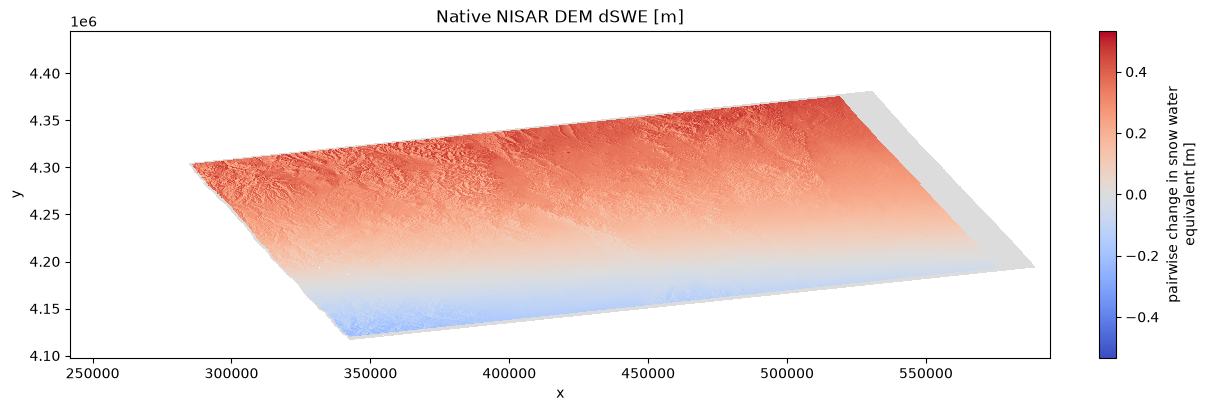

In [4]:
def fraction_finite(data):
    values = np.asarray(data)
    return float(np.isfinite(values).mean())

rows = []
if controlled_dswe is not None:
    rows.append(('controlled', controlled_dswe, FROZEN_COLORADO_WAVELENGTH_M, 'Colorado incidence raster'))
rows.append(('native', native_dswe, float(native.attrs['wavelength_m']), native.attrs.get('dem_source', 'unknown')))
table = ['<table><tr><th>Mode</th><th>Wavelength [m]</th><th>Geometry</th><th>dSWE support</th></tr>']
for name, data, wavelength, geometry in rows:
    support = fraction_finite(data)
    table.append(f'<tr><td>{name}</td><td><code>{wavelength:.9f}</code></td><td><code>{escape(str(geometry))}</code></td><td><code>{support:.6f}</code></td></tr>')
table.append('</table>')
display(HTML(''.join(table)))
display(HTML('<h4>Controlled provenance</h4><pre>' + escape(str({k: controlled.attrs.get(k) for k in ["phase_difference_definition", "phase_transform", "phase_reference_offset_rad", "wavelength_m"]})) + '</pre>') if controlled is not None else HTML(''))
display(HTML('<h4>Native provenance</h4><pre>' + escape(str({k: native.attrs.get(k) for k in ["phase_difference_definition", "phase_transform", "dem_source", "incidence_angle_source", "wavelength_m", "wavelength_source"]})) + '</pre>'))

fig, axes = plt.subplots(1, 2 if controlled_dswe is not None else 1, figsize=(12, 4), constrained_layout=True)
axes = np.atleast_1d(axes)
if controlled_dswe is not None:
    controlled_dswe.plot(ax=axes[0], cmap='coolwarm')
    axes[0].set_title('Controlled dSWE [m]')
native_dswe.plot(ax=axes[-1], cmap='coolwarm')
axes[-1].set_title('Native NISAR DEM dSWE [m]')
plt.show()

In [5]:
if DOWNSTREAM_DSWE_PATH is None or controlled_dswe is None:
    display(HTML('<p><i>Residual preview skipped: controlled mode and <code>SNOWIN_COLORADO_DOWNSTREAM_DSWE</code> are both required.</i></p>'))
else:
    import rasterio
    with rasterio.open(DOWNSTREAM_DSWE_PATH) as source:
        downstream_dswe = source.read(1)
    if downstream_dswe.shape != controlled_dswe.shape:
        raise ValueError('downstream dSWE raster does not match the GUNW grid')
    residual = np.asarray(controlled_dswe.values) + downstream_dswe
    display(HTML(f'<p>Controlled signed residual uses SnowIn dSWE + downstream dSWE, consistent with the Colorado raw-phase convention. Maximum absolute residual: <code>{np.nanmax(np.abs(residual)):.6g} m</code>.</p>'))
    xr.DataArray(downstream_dswe, dims=controlled_dswe.dims, coords=controlled_dswe.coords, name='downstream_dswe').plot(cmap='coolwarm')
    plt.title('Downstream dSWE [m]')
    plt.show()